In [54]:
import pandas as pd
import wandb

In [94]:
RUN_PATH = "amanda-mendes-cloudwalk/diffusion-finetune/5qfga8ko"

In [95]:
run = wandb.Api().run(RUN_PATH)


In [96]:
df_norm = pd.DataFrame(list(run.scan_history(keys=[f"grad_inc_norm/t={t}" for t in range(48)])))
df_mean = pd.DataFrame(list(run.scan_history(keys=[f"grad_inc_mean/t={t}" for t in range(48)])))
df_std = pd.DataFrame(list(run.scan_history(keys=[f"grad_inc_std/t={t}" for t in range(48)])))

In [97]:
# Save dataframes to CSV files
df_norm.to_csv("gradient_norm_data.csv", index=False)
df_mean.to_csv("gradient_mean_data.csv", index=False)
df_std.to_csv("gradient_std_data.csv", index=False)

print("Saved dataframes to CSV files:")
print("- gradient_norm_data.csv")
print("- gradient_mean_data.csv")
print("- gradient_std_data.csv")


Saved dataframes to CSV files:
- gradient_norm_data.csv
- gradient_mean_data.csv
- gradient_std_data.csv


In [107]:
pd.read_csv("gradient_norm_data.csv").shape

(700, 48)

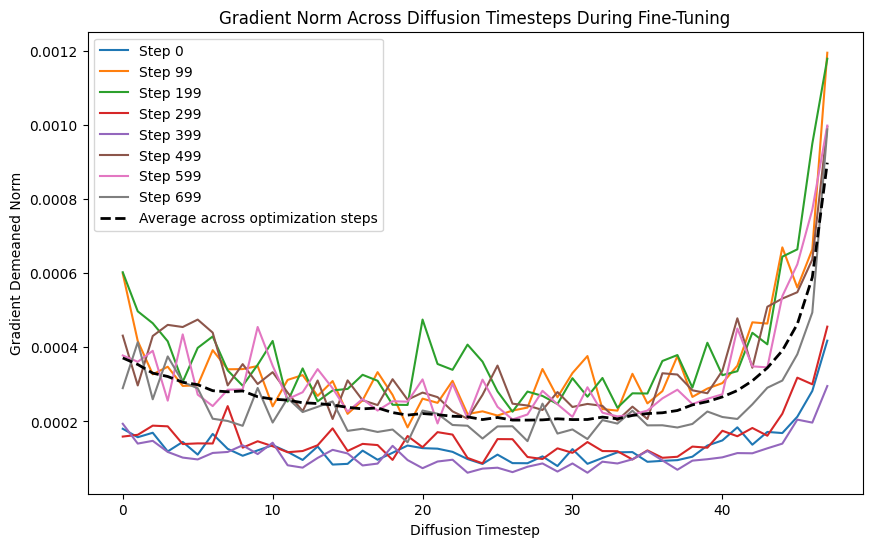

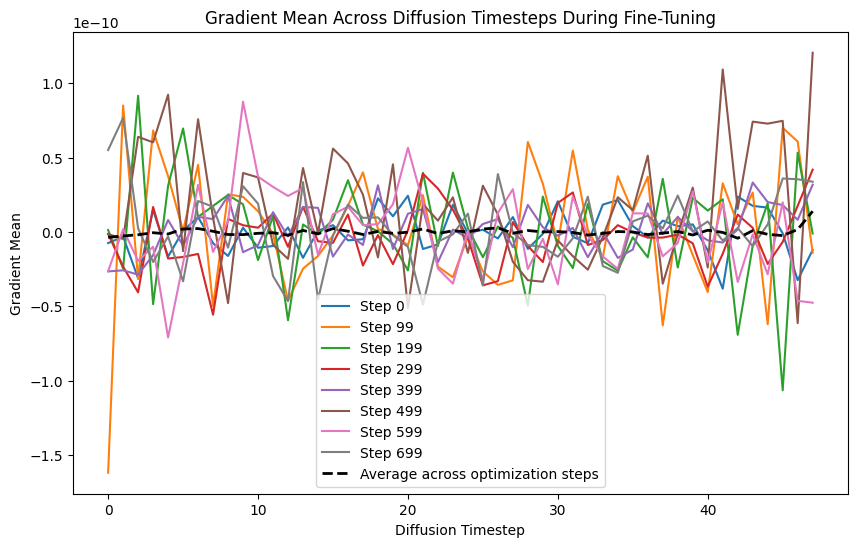

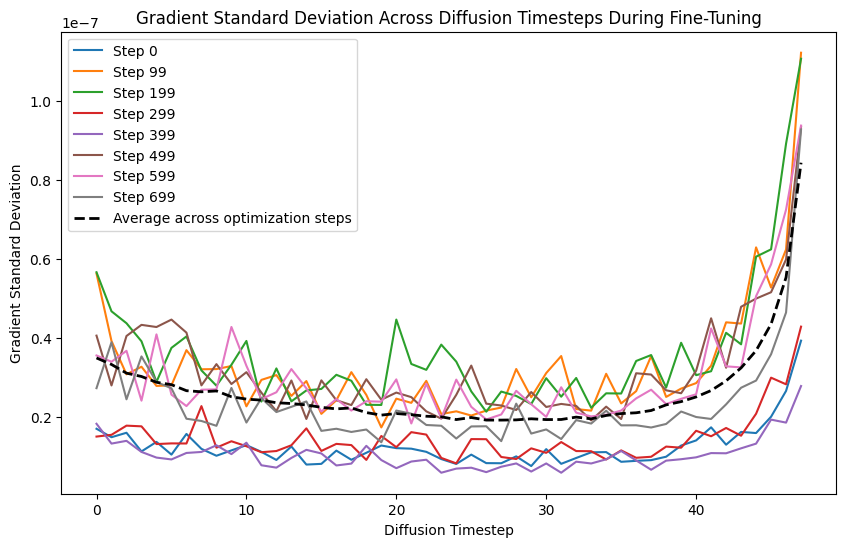

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Sample 5 uniformly distributed optimization steps 
opt_steps = np.linspace(0, len(df_norm)-1, 8, dtype=int)
diffusion_timesteps = [int(c.split("=")[1]) for c in df_norm.columns if "t=" in c]

# Define dataframes and their corresponding labels
dataframes = [
    (df_norm, "Gradient Demeaned Norm", "Gradient Norm Across Diffusion Timesteps During Fine-Tuning"),
    (df_mean, "Gradient Mean", "Gradient Mean Across Diffusion Timesteps During Fine-Tuning"),
    (df_std, "Gradient Standard Deviation", "Gradient Standard Deviation Across Diffusion Timesteps During Fine-Tuning")
]

# Create plots for each dataframe
for df, ylabel, title in dataframes:
    plt.figure(figsize=(10, 6))
    
    # Plot sample optimization steps
    for step in opt_steps:
        plt.plot(diffusion_timesteps, df.iloc[step], label=f"Step {step}")
    
    # Add the average across all steps (one value per timestep)
    gradient_cols = [col for col in df.columns if "t=" in col]
    average_across_steps = df[gradient_cols].mean(axis=0)
    plt.plot(diffusion_timesteps, average_across_steps, 'k--', linewidth=2, label="Average across optimization steps")
    
    plt.xlabel("Diffusion Timestep")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

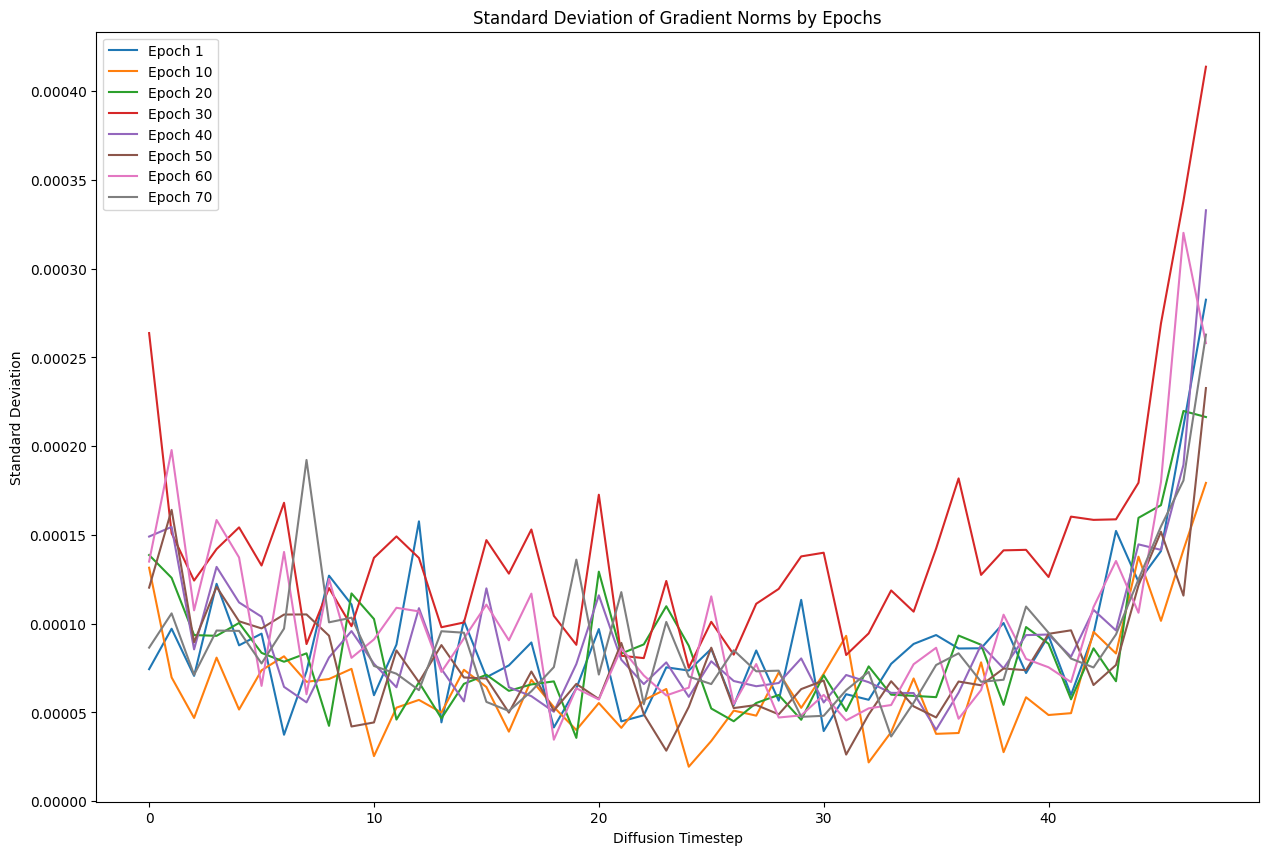

In [102]:
# Group every 5 rows and plot std for each epoch
epoch_size = 10
num_epochs = len(df_norm) // epoch_size

plt.figure(figsize=(15, 10))

# Sample 5 epochs uniformly distributed
epoch_indices = np.linspace(0, num_epochs-1, 8, dtype=int)

for i in epoch_indices:
    start_idx = i * epoch_size
    end_idx = start_idx + epoch_size
    epoch_data = df_norm.iloc[start_idx:end_idx]
    
    # Calculate std for this epoch and plot
    epoch_std = epoch_data.std()
    diffusion_timesteps = [int(c.split("=")[1]) for c in epoch_std.index if "t=" in c]
    gradient_cols = [col for col in epoch_std.index if "t=" in col]
    
    plt.plot(diffusion_timesteps, epoch_std[gradient_cols], label=f"Epoch {i+1}")

plt.xlabel("Diffusion Timestep")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation of Gradient Norms by Epochs")
plt.legend()
plt.show()

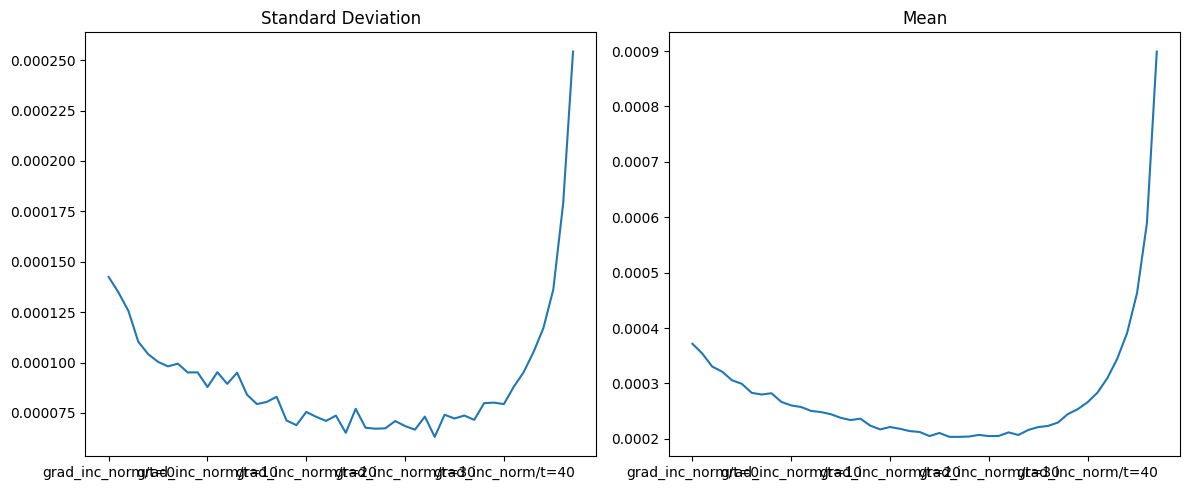

In [106]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_norm.std().plot(ax=ax1)
ax1.set_title("Standard Deviation")

df_norm.mean().plot(ax=ax2)
ax2.set_title("Mean")

plt.tight_layout()
plt.show()